# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [5]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [6]:
df = pd.read_csv('/content/personality_dataset.csv')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


Display the summary of all the features of the dataset using `.info()`

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


Display the total number of samples from each label using `.value_counts()`

In [9]:
label1 = df["Personality"].value_counts()
print(label1)

Personality
Introvert    2502
Extrovert    2498
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

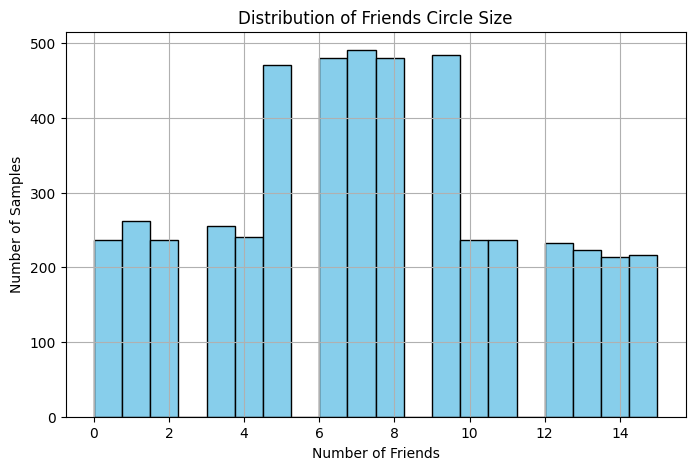

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["Friends_circle_size"].astype(float).dropna(), bins=20,
         edgecolor='black', color='skyblue')

plt.title("Distribution of Friends Circle Size")
plt.xlabel("Number of Friends")
plt.ylabel("Number of Samples")
plt.grid(True)

plt.show()

Remove the name column using `drop()` method

In [11]:
if 'name' in df.columns:
    df = df.drop('name', axis=1)
    print("Column 'name' dropped successfully.")
else:
    print("Column 'name' not found, skipping drop.")

print("\nRemaining Columns:")
for col in df.columns.tolist():
    print(f"• {col}")

print("\nData (first 5 rows):")
print(df.head().to_markdown())

Column 'name' not found, skipping drop.

Remaining Columns:
• Time_spent_Alone
• Stage_fear
• Social_event_attendance
• Going_outside
• Drained_after_socializing
• Friends_circle_size
• Post_frequency
• Personality

Data (first 5 rows):
|    |   Time_spent_Alone | Stage_fear   |   Social_event_attendance |   Going_outside | Drained_after_socializing   |   Friends_circle_size |   Post_frequency | Personality   |
|---:|-------------------:|:-------------|--------------------------:|----------------:|:----------------------------|----------------------:|-----------------:|:--------------|
|  0 |                  3 | Yes          |                         6 |               7 | No                          |                    14 |                5 | Extrovert     |
|  1 |                  2 | No           |                         8 |               6 | No                          |                     7 |                8 | Extrovert     |
|  2 |                  1 | No           |         

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [12]:
x = df.drop("Personality", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [13]:
y = df["Personality"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

Display the dimensions of each variables using `.shape()`

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train shape: (4000,)
y_test shape: (1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [19]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [22]:
y_pred = knn.predict(X_test_numeric)

## E. Evaluate the model

Create a confusion matrix

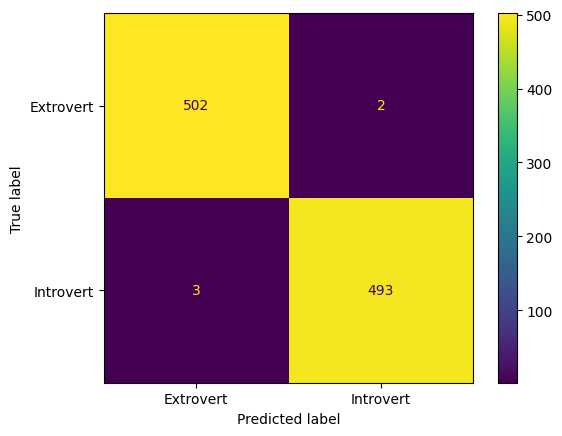

Confusion Matrix:
 [[502   2]
 [  3 493]]


In [25]:
y_test_numeric = le_y.transform(y_test)

cm = confusion_matrix(y_test_numeric, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_y.classes_)
disp.plot()
plt.show()

print("Confusion Matrix:\n", cm)

Display the accuracy

In [29]:
print("Accuracy:", accuracy_score(y_test_numeric, y_pred))

Accuracy: 0.995


Display the precision

In [30]:
print("Precision:", precision_score(y_test_numeric, y_pred, average='weighted'))

Precision: 0.9950019001900189


Display the recall

In [31]:
print("Recall:", recall_score(y_test_numeric, y_pred, average='weighted'))

Recall: 0.995


Display the f1-score

In [32]:
print("F1-score:", f1_score(y_test_numeric, y_pred, average='weighted'))

F1-score: 0.9949999549963547


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [36]:
def get_numeric_input(prompt):
    while True:
        try:
            value = int(input(prompt))
            if value < 0:
                print("Please enter a non-negative number.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a whole number.")

def get_categorical_input(prompt, valid_options, encoder):
    while True:
        user_input = input(prompt).strip().capitalize()
        if user_input in valid_options:
            return encoder.transform([user_input])[0]
        else:
            print(f"Invalid input. Please enter one of: {', '.join(valid_options)}")

print("Please enter your personal characteristics to predict your personality type:")

time_alone = get_numeric_input("1. Time spent Alone (e.g., hours per day, a number): ")
stage_fear = get_categorical_input("2. Stage fear (Yes/No): ", ['Yes', 'No'], le_x_col1)
social_attendance = get_numeric_input("3. Social event attendance (e.g., number of events per month): ")
going_outside = get_numeric_input("4. Going outside (e.g., days per week, a number): ")
drained_after_socializing = get_categorical_input("5. Drained after socializing (Yes/No): ", ['Yes', 'No'], le_x_col4)
friends_size = get_numeric_input("6. Friends circle size (e.g., number of close friends): ")
post_frequency = get_numeric_input("7. Post frequency (e.g., social media posts per week): ")

my_features = [
    [time_alone,
     stage_fear,
     social_attendance,
     going_outside,
     drained_after_socializing,
     friends_size,
     post_frequency]
]


import numpy as np
my_features_numeric = np.array(my_features, dtype=float)


my_prediction_numeric = knn.predict(my_features_numeric)

my_prediction = le_y.inverse_transform(my_prediction_numeric)[0]

print("\nPredicted Personality:", my_prediction)

Please enter your personal characteristics to predict your personality type:
1. Time spent Alone (e.g., hours per day, a number): 60
2. Stage fear (Yes/No): yes
3. Social event attendance (e.g., number of events per month): 10
4. Going outside (e.g., days per week, a number): 10
5. Drained after socializing (Yes/No): yes
6. Friends circle size (e.g., number of close friends): w
Invalid input. Please enter a whole number.
6. Friends circle size (e.g., number of close friends): 6
7. Post frequency (e.g., social media posts per week): 10

Predicted Personality: Introvert
